In [24]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

## Configuration

In [25]:
# This works when the notebook is opened from either the project root or the Kaggle folder.
DATA_DIR = Path("Kaggle") if Path("Kaggle/ct_slice_train.csv").exists() else Path(".")

TRAIN_CSV = DATA_DIR / "ct_slice_train.csv"
TEST_CSV = DATA_DIR / "ct_slice_test_noLabels.csv"
MODEL_PATH = DATA_DIR / "ct_slice_model.pt"
SUBMISSION_PATH = DATA_DIR / "submission.csv"

EPOCHS = 50
BATCH_SIZE = 256
LR = 1e-3
WEIGHT_DECAY = 1e-4
VAL_FRACTION = 0.2
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"device: {device}")

device: mps


## Load the Kaggle Data

In [26]:
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

feature_cols = [col for col in train_df.columns if col.startswith("value")]

print(f"train shape: {train_df.shape}")
print(f"test shape:  {test_df.shape}")
print(f"input features: {len(feature_cols)}")
train_df.head()

train shape: (42800, 386)
test shape:  (10700, 385)
input features: 384


,ID,value0,value1,value2,value3,value4,value5,value6,value7,value8,...,value375,value376,value377,value378,value379,value380,value381,value382,value383,TARGET
0,0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.673369,0.000000,-0.25,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.25,56.667181
1,1,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.25,62.455880
2,2,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.561189,0.791667,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.25,57.597645
3,3,0.0,0.0,0.019536,0.0,0.640917,0.875338,0.000000,0.000000,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,75.635799
4,4,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.25,54.977994


In [27]:
train_df["TARGET"].describe()

count    42800.000000
mean        47.086058
std         22.325819
min          1.738733
25%         30.005851
50%         44.060878
75%         63.752913
max         97.320148
Name: TARGET, dtype: float64

## Train/Validation Split

In [28]:
# Split before fitting normalization statistics to avoid validation leakage.
rng = np.random.default_rng(SEED)
indices = rng.permutation(len(train_df))
n_val = int(len(train_df) * VAL_FRACTION)

val_idx = indices[:n_val]
train_idx = indices[n_val:]

x_all = train_df[feature_cols].to_numpy(dtype=np.float32)
y_all = train_df["TARGET"].to_numpy(dtype=np.float32)
x_test_raw = test_df[feature_cols].to_numpy(dtype=np.float32)

x_train_raw = x_all[train_idx]
x_val_raw = x_all[val_idx]
y_train_raw = y_all[train_idx]
y_val_raw = y_all[val_idx]

print(f"train rows: {len(train_idx)}")
print(f"validation rows: {len(val_idx)}")
print(f"test rows: {len(test_df)}")

train rows: 34240
validation rows: 8560
test rows: 10700


## Normalize Inputs and Target

In [29]:
x_mean = x_train_raw.mean(axis=0)
x_std = x_train_raw.std(axis=0)
x_std[x_std == 0.0] = 1.0

x_train = (x_train_raw - x_mean) / x_std
x_val = (x_val_raw - x_mean) / x_std
x_test = (x_test_raw - x_mean) / x_std

y_mean = y_train_raw.mean()
y_std = y_train_raw.std()
y_train = (y_train_raw - y_mean) / y_std
y_val = (y_val_raw - y_mean) / y_std

print(f"target mean: {y_mean:.4f}")
print(f"target std:  {y_std:.4f}")

target mean: 47.1473
target std:  22.3496


## DataLoaders

In [30]:
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(x_train_tensor, y_train_tensor), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(x_val_tensor, y_val_tensor), batch_size=BATCH_SIZE, shuffle=False)

x_batch, y_batch = next(iter(train_loader))
print(f"x_batch shape: {x_batch.shape}")
print(f"y_batch shape: {y_batch.shape}")
print(f"train batches per epoch: {len(train_loader)}")

x_batch shape: torch.Size([256, 384])
y_batch shape: torch.Size([256, 1])
train batches per epoch: 134


## Build the Model

In [31]:
class CTRegressionMLP(nn.Module):
    def __init__(self, in_features, hidden_sizes, dropout=0.15):
        super().__init__()
        sizes = [in_features] + hidden_sizes
        layers = []

        for idx in range(len(sizes) - 1):
            layers.append(nn.Linear(sizes[idx], sizes[idx + 1]))
            layers.append(nn.BatchNorm1d(sizes[idx + 1]))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))

        layers.append(nn.Linear(sizes[-1], 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


torch.manual_seed(SEED)
model = CTRegressionMLP(in_features=len(feature_cols), hidden_sizes=[256, 128, 64], dropout=0.15).to(device)

optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
loss_fn = nn.MSELoss()

print(model)
print(f"parameters: {sum(p.numel() for p in model.parameters())}")

CTRegressionMLP(
  (net): Sequential(
    (0): Linear(in_features=384, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.15, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.15, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.15, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)
parameters: 140673


## Training Functions

In [32]:
def train_epoch(model, loader, loss_fn, optimizer):
    model.train()
    total = 0.0

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        loss = loss_fn(model(x_batch), y_batch)
        loss.backward()
        optimizer.step()

        total += loss.item() * len(x_batch)

    return total / len(loader.dataset)


def val_epoch(model, loader, loss_fn):
    model.eval()
    total = 0.0

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            loss = loss_fn(model(x_batch), y_batch)
            total += loss.item() * len(x_batch)

    return total / len(loader.dataset)


def predict_scaled(model, x_values):
    model.eval()
    preds = []
    loader = DataLoader(TensorDataset(torch.tensor(x_values, dtype=torch.float32)), batch_size=BATCH_SIZE, shuffle=False)

    with torch.no_grad():
        for (x_batch,) in loader:
            preds.append(model(x_batch.to(device)).cpu().numpy().reshape(-1))

    return np.concatenate(preds)

## Train for 50 Epochs

In [33]:
train_losses = []
val_losses = []
val_rmses = []
best_val = float("inf")
best_state = None

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, loss_fn, optimizer)
    val_loss = val_epoch(model, val_loader, loss_fn)
    val_rmse = (val_loss**0.5) * y_std

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_rmses.append(val_rmse)

    if val_loss < best_val:
        best_val = val_loss
        best_state = {name: tensor.detach().cpu().clone() for name, tensor in model.state_dict().items()}

    print(
        f"epoch {epoch:03d}: "
        f"train_mse={train_loss:.5f}, val_mse={val_loss:.5f}, val_rmse={val_rmse:.4f}"
    )

model.load_state_dict(best_state)
print(f"best validation RMSE: {(best_val**0.5) * y_std:.4f}")

epoch 001: train_mse=0.11832, val_mse=0.01400, val_rmse=2.6441
epoch 002: train_mse=0.03992, val_mse=0.00896, val_rmse=2.1153
epoch 003: train_mse=0.02953, val_mse=0.00532, val_rmse=1.6303
epoch 004: train_mse=0.02444, val_mse=0.00442, val_rmse=1.4861
epoch 005: train_mse=0.02090, val_mse=0.00386, val_rmse=1.3878
epoch 006: train_mse=0.02087, val_mse=0.00371, val_rmse=1.3619
epoch 007: train_mse=0.01825, val_mse=0.00339, val_rmse=1.3012
epoch 008: train_mse=0.01671, val_mse=0.00282, val_rmse=1.1879
epoch 009: train_mse=0.01700, val_mse=0.00374, val_rmse=1.3661
epoch 010: train_mse=0.01801, val_mse=0.00368, val_rmse=1.3567
epoch 011: train_mse=0.01591, val_mse=0.00216, val_rmse=1.0386
epoch 012: train_mse=0.01693, val_mse=0.00287, val_rmse=1.1975
epoch 013: train_mse=0.01595, val_mse=0.00258, val_rmse=1.1354
epoch 014: train_mse=0.01563, val_mse=0.00247, val_rmse=1.1112
epoch 015: train_mse=0.01566, val_mse=0.00241, val_rmse=1.0961
epoch 016: train_mse=0.01498, val_mse=0.00241, val_rmse

## Training vs Validation Loss

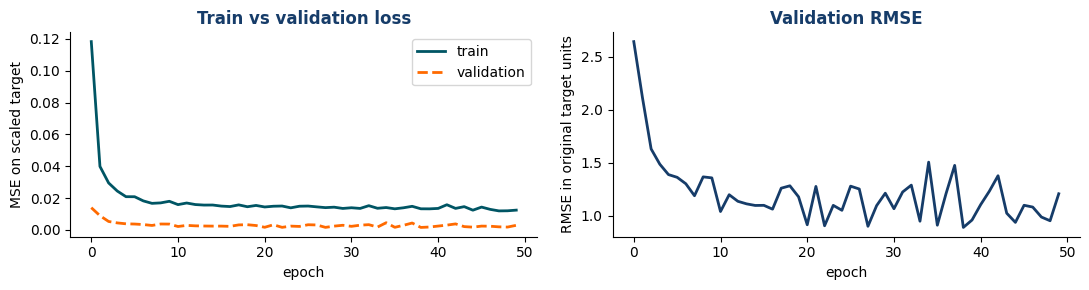

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3))

axes[0].plot(train_losses, color="#005564", linewidth=2, label="train")
axes[0].plot(val_losses, color="#FF6A00", linewidth=2, linestyle="--", label="validation")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("MSE on scaled target")
axes[0].set_title("Train vs validation loss", color="#163C69", fontweight="bold")
axes[0].legend()
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].plot(val_rmses, color="#163C69", linewidth=2)
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("RMSE in original target units")
axes[1].set_title("Validation RMSE", color="#163C69", fontweight="bold")
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## Print Some Validation Predictions

In [35]:
val_preds_scaled = predict_scaled(model, x_val)
val_preds = (val_preds_scaled * y_std) + y_mean

prediction_preview = pd.DataFrame(
    {
        "actual_TARGET": y_val_raw[:12],
        "predicted_TARGET": val_preds[:12],
        "absolute_error": np.abs(y_val_raw[:12] - val_preds[:12]),
    }
)
prediction_preview

,actual_TARGET,predicted_TARGET,absolute_error
0,86.781563,88.499924,1.718361
1,21.678965,21.792788,0.113823
2,81.057884,82.619041,1.561157
3,27.151115,27.349854,0.198738
4,52.626396,52.344200,0.282196
5,50.727444,50.381622,0.345821
6,74.314079,74.529648,0.215569
7,28.517113,27.267651,1.249462
8,67.828804,67.922775,0.093971
9,42.522243,42.065754,0.456490


## Prediction Quality Graphs

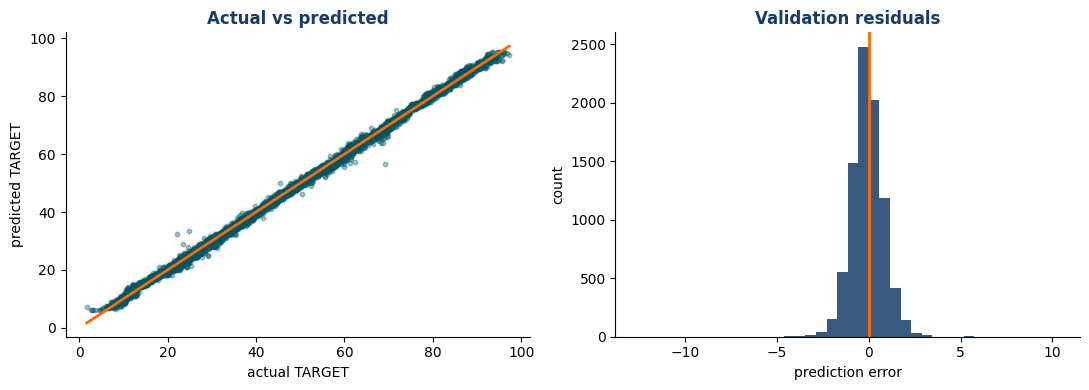

validation MAE:  0.6687
validation RMSE: 0.8884


In [36]:
residuals = val_preds - y_val_raw

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(y_val_raw, val_preds, s=10, alpha=0.35, color="#005564")
min_target = min(y_val_raw.min(), val_preds.min())
max_target = max(y_val_raw.max(), val_preds.max())
axes[0].plot([min_target, max_target], [min_target, max_target], color="#FF6A00", linewidth=2)
axes[0].set_xlabel("actual TARGET")
axes[0].set_ylabel("predicted TARGET")
axes[0].set_title("Actual vs predicted", color="#163C69", fontweight="bold")
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].hist(residuals, bins=40, color="#163C69", alpha=0.85)
axes[1].axvline(0, color="#FF6A00", linewidth=2)
axes[1].set_xlabel("prediction error")
axes[1].set_ylabel("count")
axes[1].set_title("Validation residuals", color="#163C69", fontweight="bold")
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print(f"validation MAE:  {np.mean(np.abs(residuals)):.4f}")
print(f"validation RMSE: {np.sqrt(np.mean(residuals**2)):.4f}")

## Predict Test Set and Save Submission

In [37]:
test_preds_scaled = predict_scaled(model, x_test)
test_preds = (test_preds_scaled * y_std) + y_mean

submission = pd.DataFrame({"ID": test_df["ID"], "TARGET": test_preds})
submission.to_csv(SUBMISSION_PATH, index=False)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "feature_cols": feature_cols,
        "x_mean": x_mean,
        "x_std": x_std,
        "y_mean": float(y_mean),
        "y_std": float(y_std),
        "hidden_sizes": [256, 128, 64],
        "dropout": 0.15,
        "best_val_mse_scaled": best_val,
        "best_val_rmse": (best_val**0.5) * float(y_std),
    },
    MODEL_PATH,
)

print(f"saved model: {MODEL_PATH}")
print(f"saved submission: {SUBMISSION_PATH}")
submission.head()

saved model: ct_slice_model.pt
saved submission: submission.csv


,ID,TARGET
0,42800,50.583492
1,42801,39.379444
2,42802,74.067932
3,42803,52.872135
4,42804,79.441154
